# Doğrusal Diskriminant Analizi (LDA)

- Sınıflandırma problemleri için kullanılır.

![LDA Example](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi.ytimg.com%2Fvi%2FjulEqA2ozcA%2Fmaxresdefault.jpg&f=1&nofb=1&ipt=1cb2c085944bee9f659c8dde43faff213a12bc293685187e9662495a58649fc0)

1. Sınıflar arasındaki ortalama vektörlerin hesaplanması
2. Sınıflar arasındaki dağılımın hesaplanması
3. Sınıflar arasındaki ayrımın maksimize edilmesi
4. Veri setinin dönüştürülmesi

## Durum Çalışması:

|$x_1$|$x_2$|$\text{label}$|
|:---:|:---:|:---:|
|$4$|$2$|$1$|
|$2$|$4$|$1$|
|$2$|$3$|$1$|
|$3$|$6$|$1$|
|$4$|$4$|$1$|
|$9$|$10$|$2$|
|$6$|$8$|$2$|
|$9$|$5$|$2$|
|$8$|$7$|$2$|
|$10$|$8$|$2$|

$$\mu_1 = (\overline{x_1}, \overline{x_2}) \ \ \ \ \ \mu_2 = (\overline{x_1}, \overline{x_2})$$
$$\mu_1 = (3, 3.8) \ \ \ \ \ \ \mu_2 = (8.4, 7.6)$$

*1. sınıf için kovaryans matrisi:*
$$S_1 = \sum_{x='1'} \frac{(x-\mu_1)^2}{N-1} = \begin{bmatrix} 1 & -0.25 \\ -0.25 & 2.2\end{bmatrix}$$

*2. sınıf için kovaryans matrisi:*
$$S_2 = \sum_{x='2'} \frac{(x-\mu_2)^2}{N-1} = \begin{bmatrix} 2.3 & -0.05 \\ -0.05 & 3.3\end{bmatrix}$$

$$S_1 + S_2 = \begin{bmatrix}3.3 & -0.3 \\ -0.3 & 5.5\end{bmatrix} = S_w$$

*$w$: Within Class Scattering Matrix*

$$\text{eigen value} = S_w^{-1}(\mu_1 - \mu_2) = \begin{bmatrix}0.9 \\ 0.41\end{bmatrix}$$

$$LD = w_i \cdot x_i$$
$$\downarrow$$
$$LD_1 = x_1 \cdot w_1 + x_2 \cdot w_2$$
$$LD_1 = 0.9 \cdot 4 + 2 \cdot 0.41 = 4.4$$
$$\downarrow$$
|$x_1$|$x_2$|$\text{label}$|$\text{LD}$|
|:---:|:---:|:---:|:---:|
|$4$|$2$|$1$|$4.4$|
|$2$|$4$|$1$|$3.4$|
|$2$|$3$|$1$|$3$|
|$3$|$6$|$1$|$5.2$|
|$4$|$4$|$1$|$5.3$|
|$9$|$10$|$2$|$12.3$|
|$6$|$8$|$2$|$8.8$|
|$9$|$5$|$2$|$10.2$|
|$8$|$7$|$2$|$10.2$|
|$10$|$8$|$2$|$12.4$|


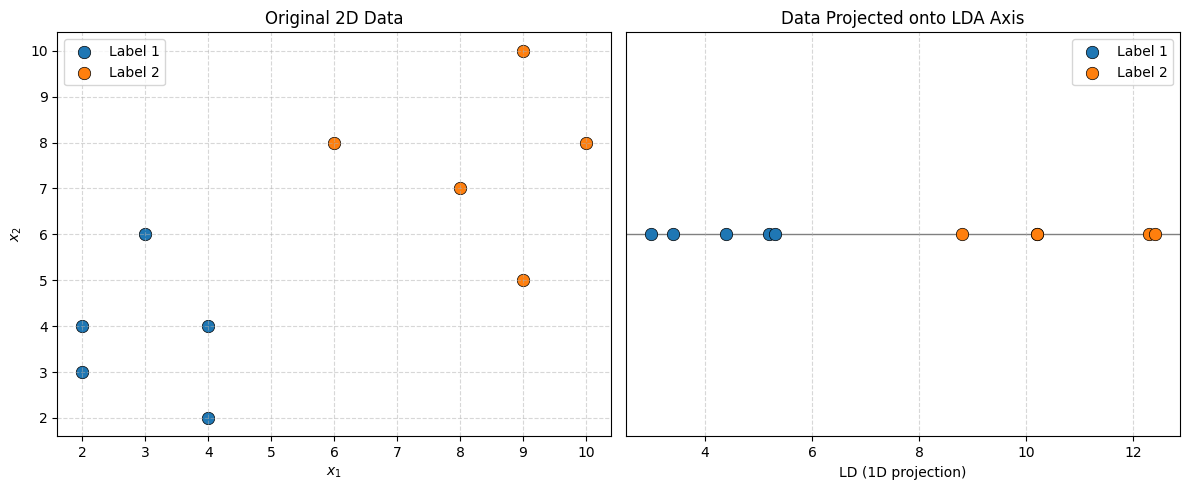

In [ ]:
import matplotlib.pyplot as plt
 
# --- Data from the table ---
x1 = [4, 2, 2, 3, 4, 9, 6, 9, 8, 10]
x2 = [2, 4, 3, 6, 4, 10, 8, 5, 7, 8]
label = [1, 1, 1, 1, 1, 2, 2, 2, 2, 2]
LD = [4.4, 3.4, 3.0, 5.2, 5.3, 12.3, 8.8, 10.2, 10.2, 12.4]
 
# --- Consistent color mapping per label ---
colors = {1: "tab:blue", 2: "tab:orange"}
point_colors = [colors[l] for l in label]
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# --- Plot 1: original 2D data (x1, x2) colored by label ---
for lbl in sorted(colors.keys()):
    xs = [x1[i] for i in range(len(label)) if label[i] == lbl]
    ys = [x2[i] for i in range(len(label)) if label[i] == lbl]
    ax1.scatter(xs, ys, c=colors[lbl], label=f"Label {lbl}", s=80,
                edgecolors="black", linewidths=0.5)
 
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_title("Original 2D Data")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)
 
# --- Plot 2: 1D projection (LD) onto a line ---
# All points plotted at y=0 to represent the 1D line; a small jitter
# could be added, but keeping y=0 shows the true "condensed" nature.
for lbl in sorted(colors.keys()):
    lds = [LD[i] for i in range(len(label)) if label[i] == lbl]
    ax2.scatter(lds, [0] * len(lds), c=colors[lbl], label=f"Label {lbl}",
                s=80, edgecolors="black", linewidths=0.5)
 
ax2.axhline(0, color="gray", linewidth=1, zorder=0)
ax2.set_yticks([])
ax2.set_xlabel("LD (1D projection)")
ax2.set_title("Data Projected onto LDA Axis")
ax2.legend()
ax2.grid(True, axis="x", linestyle="--", alpha=0.5)
 
plt.tight_layout()
# plt.savefig("lda_projection.png", dpi=150)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Wine.csv")
X = data.iloc[:,:13].values
Y = data.iloc[:,13].values

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

In [2]:
data['Customer_Segment'].nunique()

3

## LDA:

*Important: When fiting LDA, you give y_train value with X_train value because you LDA maximises the distance between classes.\
Another thing to point out is that the maximum number of components that LDA can generate can calculated with the following:*

$$\text{min(n\_features, n\_classes - 1)}$$

*In this case:*
- `n_features=13` *(columns in* `X_train` *after scaling)*
- `n_classes=3` *(number of unique values in* `Customer_Segment`*)*

Thus:

$$\text{n\_components} \le min(13,3-1) = 2$$

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)

In [4]:
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train_lda,y_train)

classifier2 = LogisticRegression(random_state=0)
classifier2.fit(X_train,y_train)

y_pred_lda = classifier.predict(X_test_lda)
y_pred = classifier2.predict(X_test)

from sklearn.metrics import confusion_matrix

### LDA Results Confusion Matrix:

In [6]:
confusion_matrix(y_test, y_pred_lda)

array([[20,  0,  0],
       [ 0, 24,  0],
       [ 0,  0, 15]], dtype=int64)

### Non-LDA Results Confusion Matrix:

In [7]:
confusion_matrix(y_test,y_pred)

array([[20,  0,  0],
       [ 0, 24,  0],
       [ 0,  0, 15]], dtype=int64)

### LDA & Non-LDA Confusion Matrix:

In [8]:
confusion_matrix(y_pred_lda, y_pred)

array([[20,  0,  0],
       [ 0, 24,  0],
       [ 0,  0, 15]], dtype=int64)